# Decision Tree with scikit-learn
`DecisionTreeClassifier` on Iris — full sklearn pipeline with visualisation,
pruning analysis, and cost-complexity pruning. Model saved to `../Models/dt_sklearn.joblib`.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

iris        = load_iris()
features    = list(iris.feature_names)
class_names = list(iris.target_names)
X, y        = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 120  |  Test: 30


## 2. Fit Decision Tree

In [2]:
dt = DecisionTreeClassifier(
    criterion    = 'gini',
    max_depth    = 4,
    min_samples_split = 2,
    random_state = 42
)
dt.fit(X_train, y_train)

print(f"Tree depth  : {dt.get_depth()}")
print(f"Leaf nodes  : {dt.get_n_leaves()}")
print(f"Train Acc   : {accuracy_score(y_train, dt.predict(X_train)):.4f}")
print(f"Test  Acc   : {accuracy_score(y_test,  dt.predict(X_test)):.4f}")

Tree depth  : 4
Leaf nodes  : 7
Train Acc   : 0.9917
Test  Acc   : 0.9333


## 3. Tree Visualisation

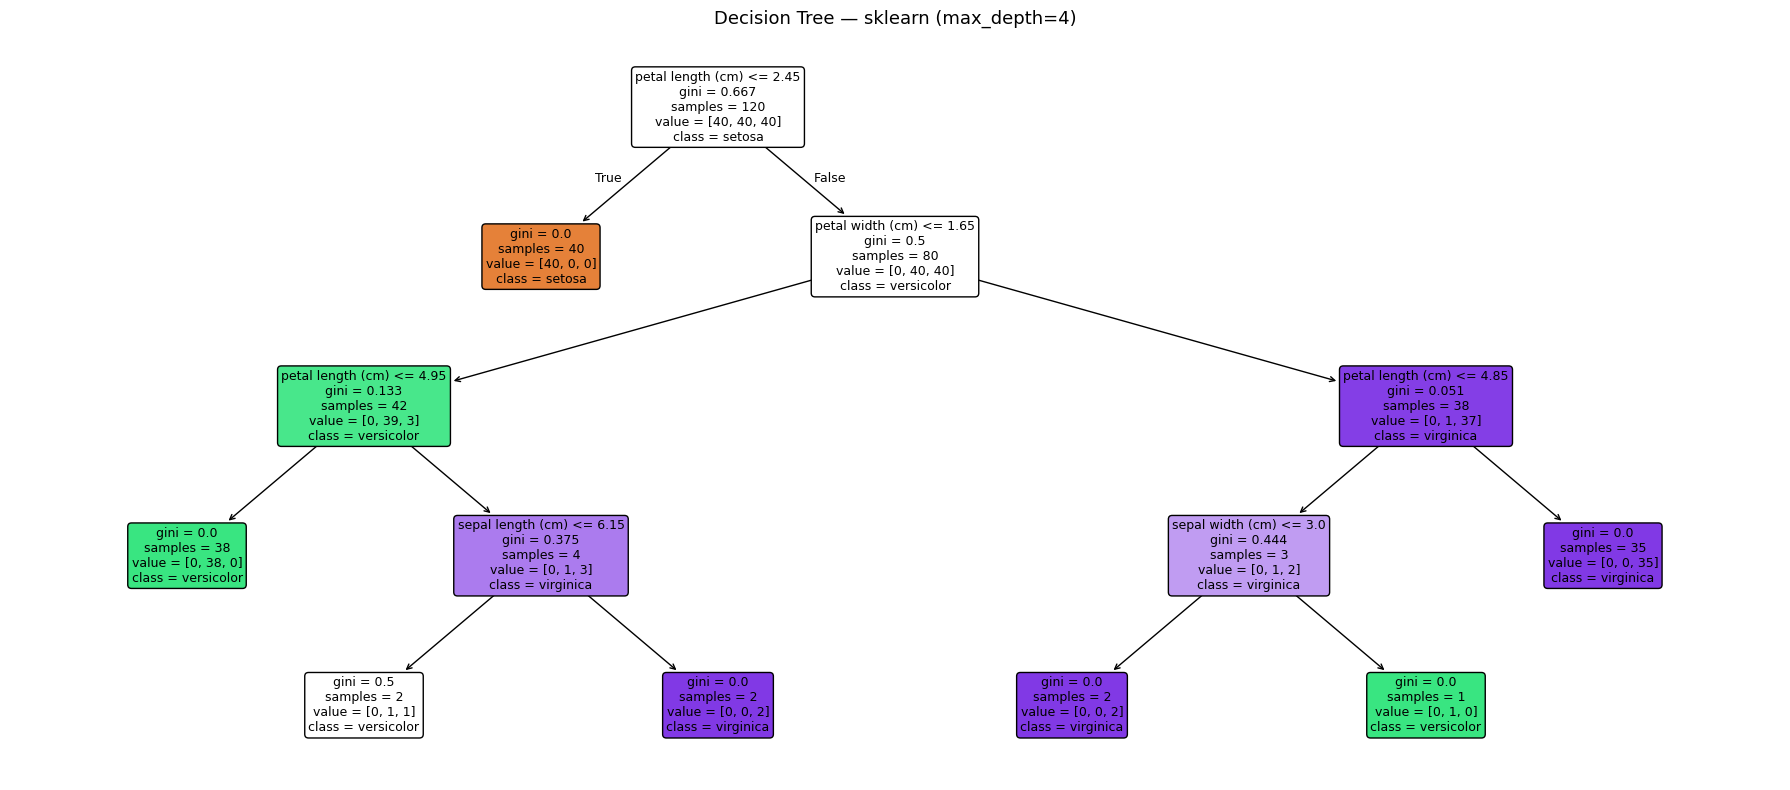

In [3]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt, feature_names=features, class_names=class_names,
          filled=True, rounded=True, ax=ax, fontsize=9)
ax.set_title('Decision Tree — sklearn (max_depth=4)', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Text Rule Export

In [4]:
rules = export_text(dt, feature_names=features)
print(rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- sepal length (cm) <= 6.15
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  6.15
|   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.00
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.00
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



## 5. Evaluation

In [5]:
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)
auc     = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

print(classification_report(y_test, y_pred, target_names=class_names))
print(f"ROC-AUC (OVR macro): {auc:.4f}")

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

ROC-AUC (OVR macro): 0.9733


## 6. Confusion Matrix

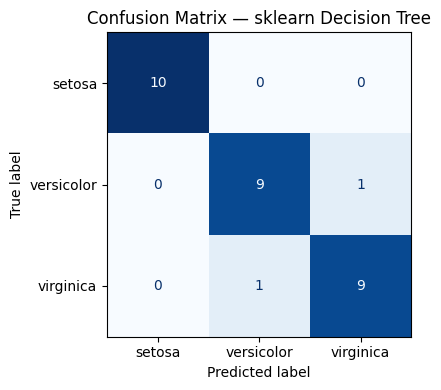

In [6]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — sklearn Decision Tree')
plt.tight_layout(); plt.show()

## 7. Feature Importance (Gini Decrease)

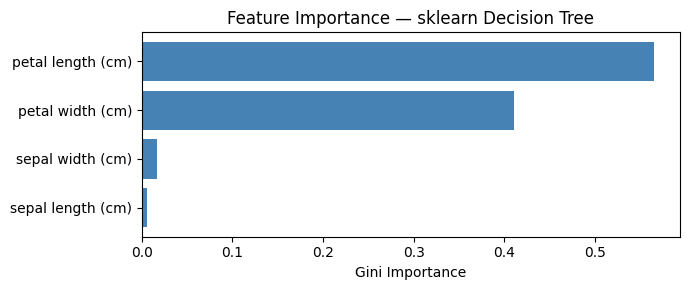

,importance
petal length (cm),0.5656
petal width (cm),0.4112
sepal width (cm),0.0169
sepal length (cm),0.0063


In [7]:
imp   = dt.feature_importances_
order = np.argsort(imp)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh([features[i] for i in order], imp[order], color='steelblue')
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance — sklearn Decision Tree')
plt.tight_layout(); plt.show()

pd.Series(imp, index=features).sort_values(ascending=False).round(4).to_frame('importance')

## 8. Effect of max_depth

Deeper trees memorise training data (overfit). Cross-validation finds the sweet spot.

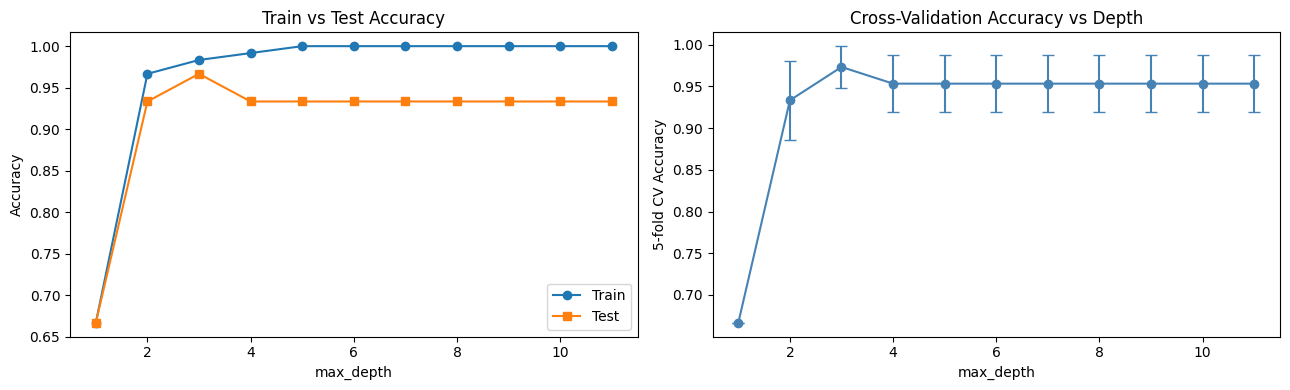

In [8]:
depths   = range(1, 12)
tr_accs, te_accs, cv_means, cv_stds = [], [], [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    tr_accs.append(accuracy_score(y_train, m.predict(X_train)))
    te_accs.append(accuracy_score(y_test,  m.predict(X_test)))
    cv = cross_val_score(m, X, y, cv=5)
    cv_means.append(cv.mean()); cv_stds.append(cv.std())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(depths, tr_accs, marker='o', label='Train')
ax1.plot(depths, te_accs, marker='s', label='Test')
ax1.set_xlabel('max_depth'); ax1.set_ylabel('Accuracy')
ax1.set_title('Train vs Test Accuracy'); ax1.legend()

ax2.errorbar(depths, cv_means, yerr=cv_stds, marker='o', capsize=4, color='steelblue')
ax2.set_xlabel('max_depth'); ax2.set_ylabel('5-fold CV Accuracy')
ax2.set_title('Cross-Validation Accuracy vs Depth')
plt.tight_layout(); plt.show()

## 9. Cost-Complexity Pruning (ccp_alpha)

sklearn's post-pruning removes subtrees that don't reduce impurity enough relative
to their complexity. `ccp_alpha=0` → no pruning; larger values → more aggressive.

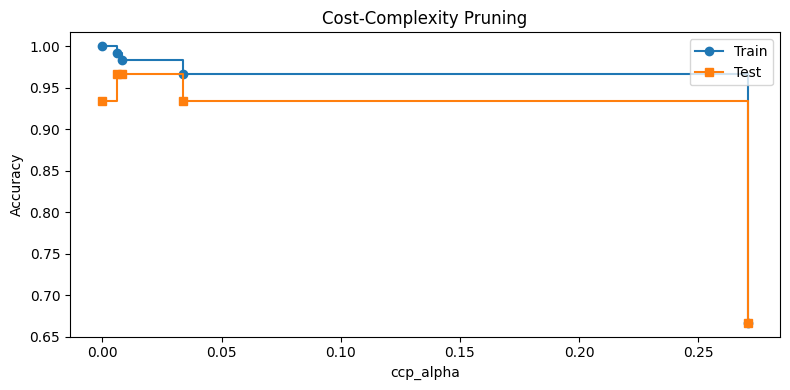

In [9]:
path   = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]    # last alpha gives a single-node tree — skip

tr_a, te_a = [], []
for alpha in alphas:
    m = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42).fit(X_train, y_train)
    tr_a.append(accuracy_score(y_train, m.predict(X_train)))
    te_a.append(accuracy_score(y_test,  m.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, tr_a, marker='o', label='Train', drawstyle='steps-post')
ax.plot(alphas, te_a, marker='s', label='Test',  drawstyle='steps-post')
ax.set_xlabel('ccp_alpha'); ax.set_ylabel('Accuracy')
ax.set_title('Cost-Complexity Pruning')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Decision Boundary (2 Features)

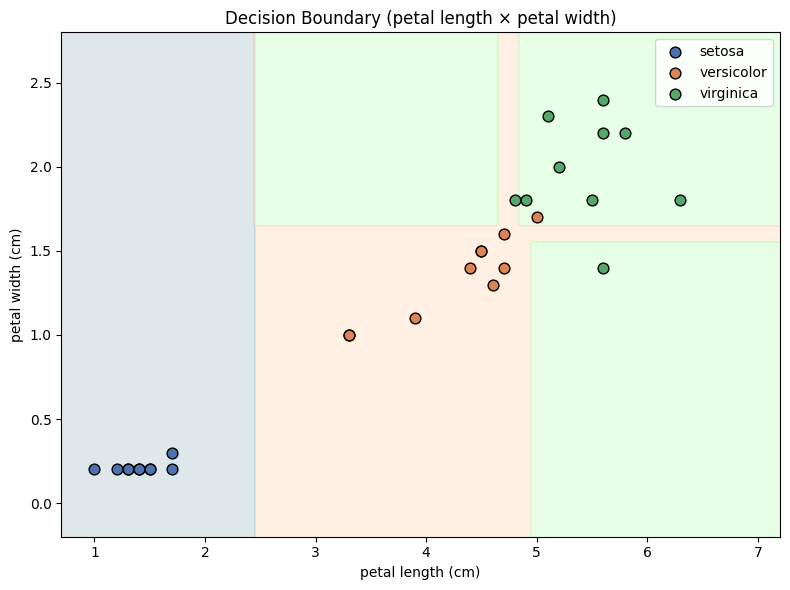

In [10]:
# Use petal length and petal width (most discriminative)
feat_idx = [2, 3]
X2_train = X_train[:, feat_idx]
X2_test  = X_test[:, feat_idx]

dt2 = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X2_train, y_train)

x_min, x_max = X[:, feat_idx[0]].min()-0.3, X[:, feat_idx[0]].max()+0.3
y_min, y_max = X[:, feat_idx[1]].min()-0.3, X[:, feat_idx[1]].max()+0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

colors_bg = ['#AEC6CF', '#FFDAB9', '#C3FFC3']
colors_pt = ['#4C72B0', '#DD8452', '#55A868']
cmap_bg   = plt.matplotlib.colors.ListedColormap(colors_bg)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
for cls, col, name in zip([0,1,2], colors_pt, class_names):
    mask = y_test == cls
    ax.scatter(X2_test[mask, 0], X2_test[mask, 1], color=col, label=name, edgecolors='k', s=60)
ax.set_xlabel(features[feat_idx[0]]); ax.set_ylabel(features[feat_idx[1]])
ax.set_title('Decision Boundary (petal length × petal width)')
ax.legend(); plt.tight_layout(); plt.show()

## 11. Save Model to `../Models/`

In [11]:


save_path = '../Models/dt_sklearn.joblib'
joblib.dump(dt, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/dt_sklearn.joblib  (2.4 KB)
